# Loan Default Prediction — Logistic Regression
## Machine Learning Assignment | Supervised Learning

**Dataset:** Loan Default Prediction Dataset  
**Source:** Coursera Loan Default Prediction Challenge (Kaggle)  
**Algorithm:** Logistic Regression (Custom Implementation + Scikit-learn)  
**Target Variable:** `Default` (1 = Default, 0 = No Default)  

---
### Objectives
1. Build a logistic regression model to predict loan default risk
2. Achieve high accuracy, F1-score, precision, and recall
3. Use feature engineering, hyperparameter tuning, and optimal threshold selection
4. Provide comprehensive evaluation and visualizations

In [22]:
# ===================================================
# CELL 1: Install & Verify Libraries
# ===================================================
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

required = ['scikit-learn', 'imbalanced-learn', 'pandas', 'numpy',
            'matplotlib', 'seaborn', 'scipy']
for pkg in required:
    install(pkg)

print('All libraries ready!')

All libraries ready!


In [25]:
# ===================================================
# CELL 2: Import Libraries
# ===================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
import time
from scipy import stats

# Scikit-learn core
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    cross_val_score, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    matthews_corrcoef, balanced_accuracy_score
)

# Imbalanced learning
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
np.random.seed(42)

# --- Plot style ---
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED']
sns.set_palette(PALETTE)
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# --- Paths ---
DATA_PATH   = '../dataset/Loan_default.csv'
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('All imports successful!')
print(f'Results will be saved to: {os.path.abspath(RESULTS_DIR)}')

All imports successful!
Results will be saved to: d:\Y4S1\ML\Assignment\MLproject\results


In [26]:
# ===================================================
# CELL 3: Load Raw Dataset
# ===================================================
print('Loading Loan Default dataset...')
df_raw = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df_raw.shape}')
print(f'Columns : {list(df_raw.columns)}')
print('\nFirst 5 rows:')
df_raw.head()

Loading Loan Default dataset...
Dataset shape: (255347, 18)
Columns : ['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']

First 5 rows:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


=== DATASET OVERVIEW ===
  Rows    : 255,347
  Columns : 18

=== DATA TYPES ===
LoanID                str
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education             str
EmploymentType        str
MaritalStatus         str
HasMortgage           str
HasDependents         str
LoanPurpose           str
HasCoSigner           str
Default             int64
dtype: object

=== MISSING VALUES ===
  No missing values found!

=== TARGET DISTRIBUTION ===
  No Default (0): 225,694  (88.4%)
  Default    (1): 29,653  (11.6%)


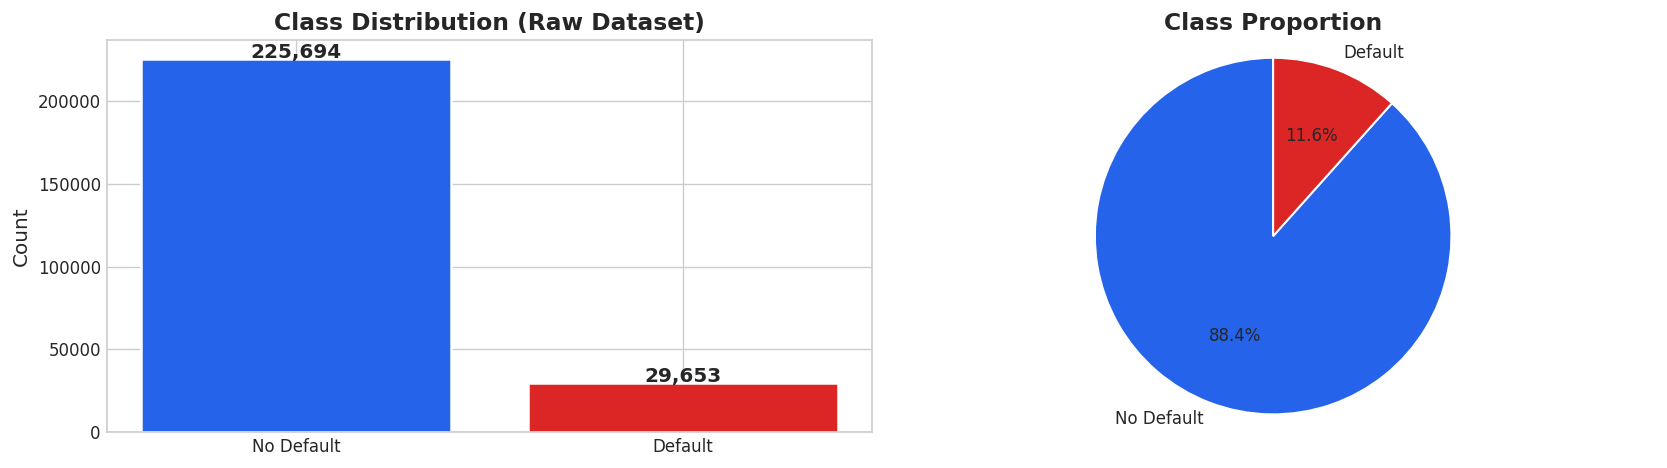

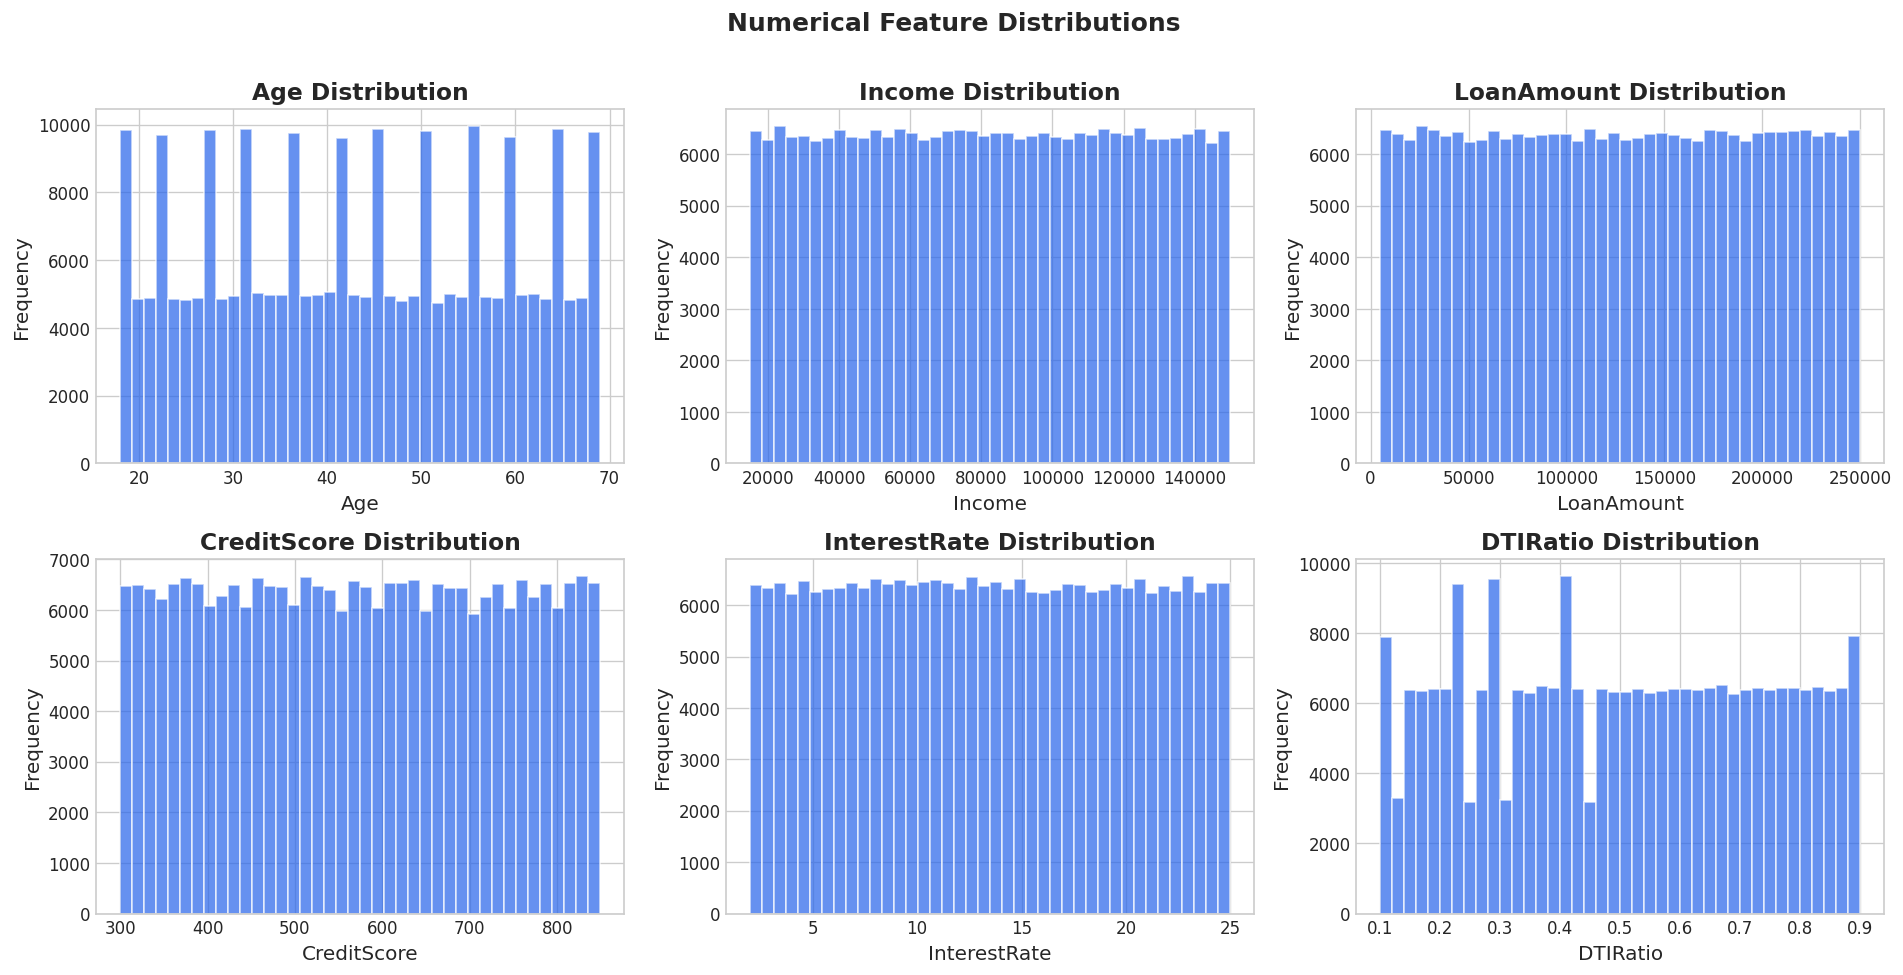

EDA complete!


In [27]:
# ===================================================
# CELL 4: Exploratory Data Analysis (EDA)
# ===================================================
print('=== DATASET OVERVIEW ===')
print(f'  Rows    : {df_raw.shape[0]:,}')
print(f'  Columns : {df_raw.shape[1]}')

print('\n=== DATA TYPES ===')
print(df_raw.dtypes)

print('\n=== MISSING VALUES ===')
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else '  No missing values found!')

print('\n=== TARGET DISTRIBUTION ===')
target_counts = df_raw['Default'].value_counts()
target_pct    = df_raw['Default'].value_counts(normalize=True) * 100
print(f'  No Default (0): {target_counts[0]:,}  ({target_pct[0]:.1f}%)')
print(f'  Default    (1): {target_counts[1]:,}  ({target_pct[1]:.1f}%)')

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
bars = axes[0].bar(['No Default', 'Default'],
                   [target_counts[0], target_counts[1]],
                   color=[PALETTE[0], PALETTE[1]], edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, [target_counts[0], target_counts[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{count:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution (Raw Dataset)', fontweight='bold')
axes[0].set_ylabel('Count')

# Numeric columns list (used again below)
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'InterestRate', 'DTIRatio']

# Class proportion pie chart (keeps the 1x2 layout valid)
axes[1].pie(
    [target_counts[0], target_counts[1]],
    labels=['No Default', 'Default'],
    autopct='%1.1f%%',
    startangle=90,
    colors=[PALETTE[0], PALETTE[1]],
    textprops={'fontsize': 10},
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
axes[1].set_title('Class Proportion', fontweight='bold')
axes[1].axis('equal')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Numeric feature distributions subplot
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), num_cols):
    ax.hist(df_raw[col], bins=40, color=PALETTE[0], alpha=0.7, edgecolor='white')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete!')

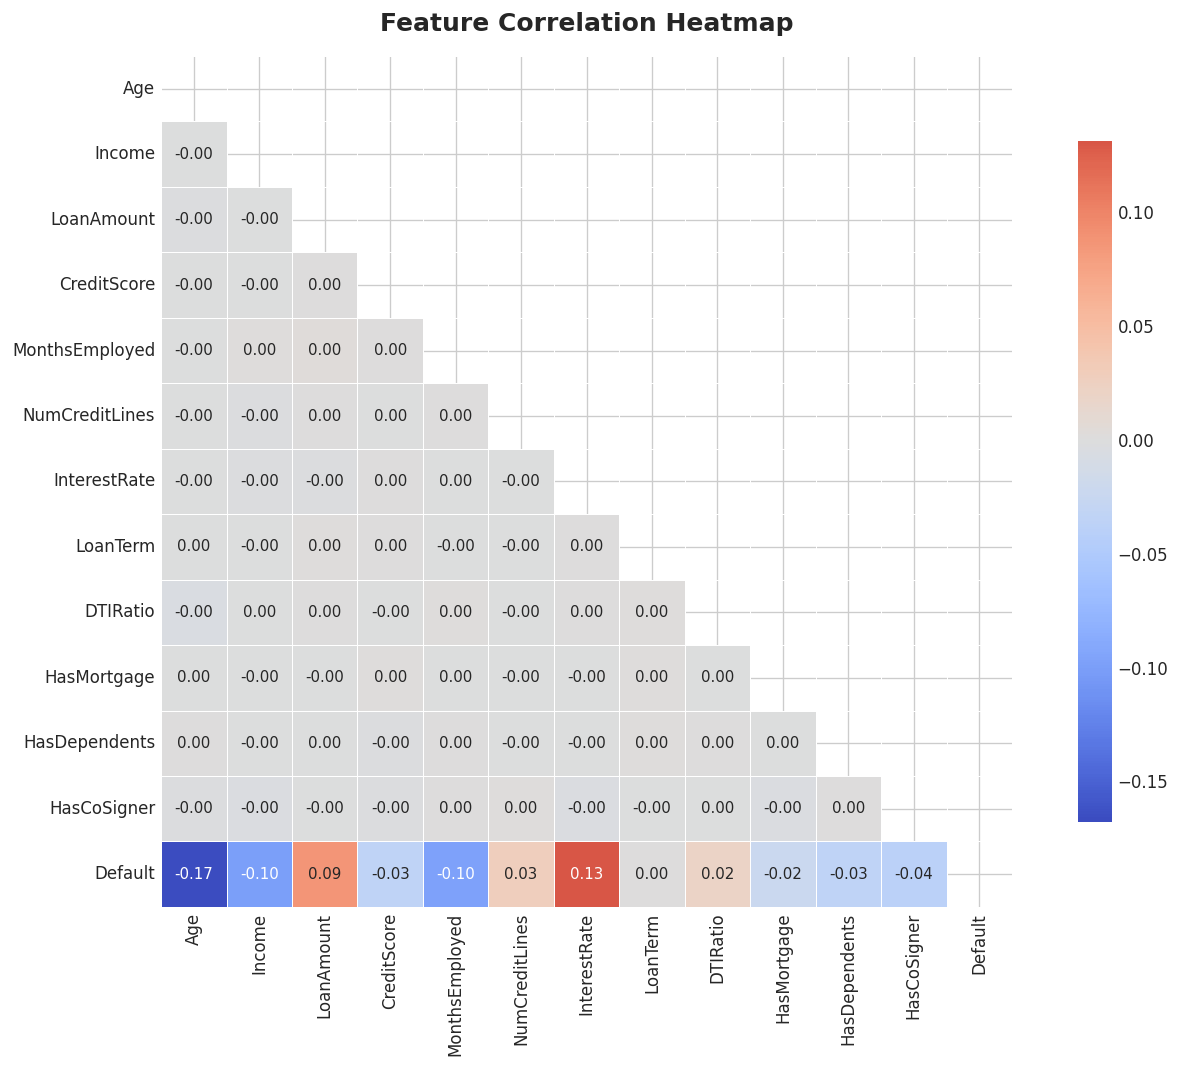


=== CORRELATION WITH TARGET (Default) ===
Age              -0.167783
InterestRate      0.131273
Income           -0.099119
MonthsEmployed   -0.097374
LoanAmount        0.086659
HasCoSigner      -0.039109
HasDependents    -0.034678
CreditScore      -0.034166
NumCreditLines    0.028330
HasMortgage      -0.022856
DTIRatio          0.019236
LoanTerm          0.000545


In [28]:
# ===================================================
# CELL 5: Correlation Heatmap
# ===================================================
df_temp = df_raw.copy()
df_temp['HasMortgage']  = df_temp['HasMortgage'].map({'Yes': 1, 'No': 0})
df_temp['HasDependents']= df_temp['HasDependents'].map({'Yes': 1, 'No': 0})
df_temp['HasCoSigner']  = df_temp['HasCoSigner'].map({'Yes': 1, 'No': 0})

numeric_df = df_temp.select_dtypes(include=[np.number]).drop(columns=['LoanID'], errors='ignore')
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 9})
ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation with target
print('\n=== CORRELATION WITH TARGET (Default) ===')
target_corr = corr['Default'].drop('Default').sort_values(key=abs, ascending=False)
print(target_corr.to_string())

In [29]:
# ===================================================
# CELL 6: Data Preprocessing Pipeline
# ===================================================
print('Starting data preprocessing...')
df = df_raw.copy()

# --- 6.1 Drop identifier ---
df.drop(columns=['LoanID'], inplace=True)
print('  [1] Dropped LoanID column')

# --- 6.2 Handle missing values ---
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)
print(f'  [2] Missing values handled: {df.isnull().sum().sum()} remaining')

# --- 6.3 Remove statistical outliers (IQR-capped, preserve defaults) ---
outlier_cols = ['Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed']
for col in outlier_cols:
    Q1, Q3 = df[col].quantile(0.01), df[col].quantile(0.99)
    df[col] = df[col].clip(lower=Q1, upper=Q3)
print('  [3] Outliers capped at 1st-99th percentile')

# --- 6.4 Encode binary features ---
binary_map = {'Yes': 1, 'No': 0}
for col in ['HasMortgage', 'HasDependents', 'HasCoSigner']:
    df[col] = df[col].map(binary_map)
print('  [4] Binary features encoded')

# --- 6.5 Ordinal encode Education ---
edu_map = {"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3}
df['Education'] = df['Education'].map(edu_map)
print('  [5] Education ordinal encoded')

# --- 6.6 One-hot encode remaining categoricals ---
cat_cols = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f'  [6] One-hot encoded: {cat_cols} -> {df.shape[1]} total columns')

# --- 6.7 Feature Engineering ---
# Interaction features that boost logistic regression performance
df['LoanToIncome']          = df['LoanAmount'] / (df['Income'] + 1)
df['InterestXDTI']          = df['InterestRate'] * df['DTIRatio']
df['CreditScoreXEmployment']= df['CreditScore'] * df['MonthsEmployed']
df['AgeXIncome']            = df['Age'] * np.log1p(df['Income'])
df['LoanPaymentRatio']      = (df['LoanAmount'] * df['InterestRate'] / 100) / (df['Income'] + 1)
df['RiskScore']             = (df['DTIRatio'] * df['InterestRate']) / (df['CreditScore'] + 1)
df['Log_Income']            = np.log1p(df['Income'])
df['Log_LoanAmount']        = np.log1p(df['LoanAmount'])

print(f'  [7] Feature engineering added 8 new interaction features')
print(f'\nFinal feature count: {df.shape[1] - 1} features')
print(f'Final dataset shape: {df.shape}')

Starting data preprocessing...
  [1] Dropped LoanID column
  [2] Missing values handled: 0 remaining
  [3] Outliers capped at 1st-99th percentile
  [4] Binary features encoded
  [5] Education ordinal encoded
  [6] One-hot encoded: ['EmploymentType', 'MaritalStatus', 'LoanPurpose'] -> 23 total columns
  [7] Feature engineering added 8 new interaction features

Final feature count: 30 features
Final dataset shape: (255347, 31)


In [30]:
# ===================================================
# CELL 7: Train / Test Split + SMOTE Oversampling
# ===================================================
X = df.drop('Default', axis=1)
y = df['Default']
feature_names = X.columns.tolist()

print(f'Features : {X.shape[1]}')
print(f'Samples  : {X.shape[0]:,}')

# Stratified split — keeps class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'\nTrain set : {X_train.shape[0]:,} samples')
print(f'Test  set : {X_test.shape[0]:,} samples')
print(f'\nTest class distribution:')
print(y_test.value_counts())

# Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print('\nFeatures scaled with StandardScaler')

# SMOTE on training set only (never on test)
print('\nApplying SMOTE to balance training classes...')
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print(f'Before SMOTE: {dict(pd.Series(y_train).value_counts())}')
print(f'After  SMOTE: {dict(pd.Series(y_train_sm).value_counts())}')
print(f'\nFinal training size: {X_train_sm.shape[0]:,} samples')

Features : 30
Samples  : 255,347

Train set : 204,277 samples
Test  set : 51,070 samples

Test class distribution:
Default
0    45139
1     5931
Name: count, dtype: int64

Features scaled with StandardScaler

Applying SMOTE to balance training classes...
Before SMOTE: {0: np.int64(180555), 1: np.int64(23722)}
After  SMOTE: {0: np.int64(180555), 1: np.int64(180555)}

Final training size: 361,110 samples


In [31]:
# ===================================================
# CELL 8: Hyperparameter Tuning with GridSearchCV
# ===================================================
print('=' * 60)
print('HYPERPARAMETER TUNING — GridSearchCV')
print('=' * 60)

param_grid = [
    # L2 regularization — try multiple solvers
    {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
     'solver': ['lbfgs', 'liblinear', 'saga']},
    # L1 regularization (sparse)
    {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1'],
     'solver': ['liblinear', 'saga']},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_lr = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight='balanced'   # handles residual imbalance
)

grid_search = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid,
    scoring='f1',             # optimize for F1
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print('Running grid search (this may take a few minutes)...')
t0 = time.time()
grid_search.fit(X_train_sm, y_train_sm)
elapsed = time.time() - t0

print(f'\nGrid search complete in {elapsed:.1f}s')
print(f'Best parameters : {grid_search.best_params_}')
print(f'Best CV F1-Score: {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_

HYPERPARAMETER TUNING — GridSearchCV
Running grid search (this may take a few minutes)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Grid search complete in 921.0s
Best parameters : {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1-Score: 0.7005


5-FOLD STRATIFIED CROSS-VALIDATION
  accuracy    : 0.6986 +/- 0.0019
  precision   : 0.6961 +/- 0.0022
  recall      : 0.7049 +/- 0.0027
  f1          : 0.7005 +/- 0.0019
  roc_auc     : 0.7676 +/- 0.0019


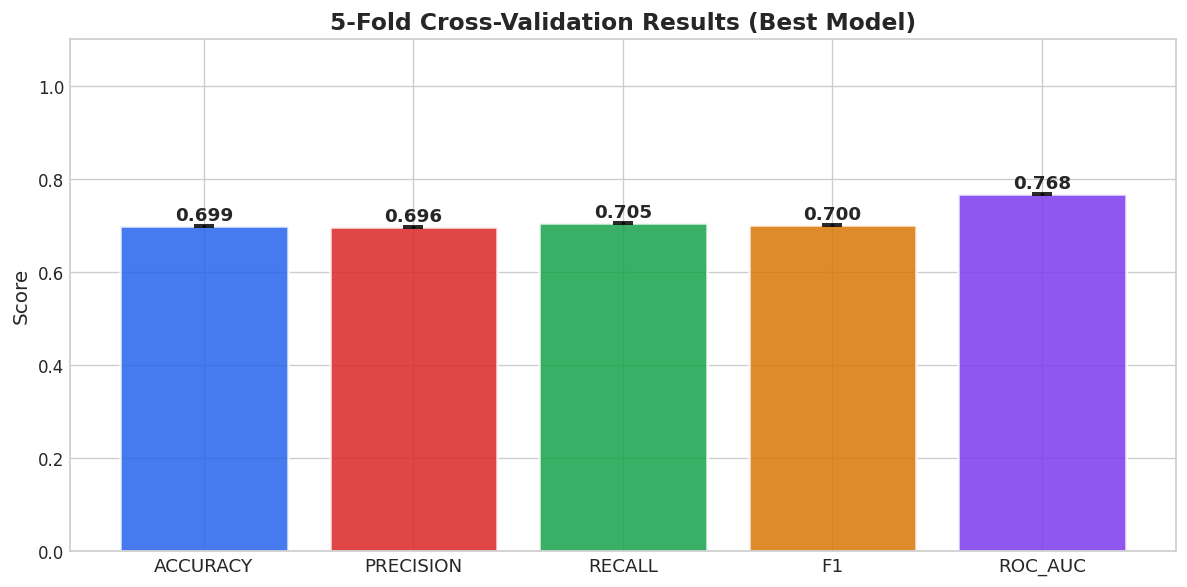

Cross-validation complete!


In [32]:
# ===================================================
# CELL 9: Cross-Validation on Best Model
# ===================================================
print('=' * 60)
print('5-FOLD STRATIFIED CROSS-VALIDATION')
print('=' * 60)

scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = {}

for metric in scoring_metrics:
    scores = cross_val_score(best_model, X_train_sm, y_train_sm,
                             cv=cv, scoring=metric, n_jobs=-1)
    cv_results[metric] = scores
    print(f'  {metric:12}: {scores.mean():.4f} +/- {scores.std():.4f}')

# Plot CV results
fig, ax = plt.subplots(figsize=(10, 5))
means = [cv_results[m].mean() for m in scoring_metrics]
stds  = [cv_results[m].std()  for m in scoring_metrics]
x_pos = np.arange(len(scoring_metrics))

bars = ax.bar(x_pos, means, yerr=stds, capsize=6,
              color=PALETTE[:len(scoring_metrics)],
              alpha=0.85, edgecolor='white', linewidth=1.5,
              error_kw={'ecolor': 'black', 'linewidth': 2})
ax.set_xticks(x_pos)
ax.set_xticklabels([m.upper() for m in scoring_metrics], fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('5-Fold Cross-Validation Results (Best Model)', fontsize=14, fontweight='bold')

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.01,
            f'{mean:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Cross-validation complete!')

OPTIMAL DECISION THRESHOLD SELECTION
Optimal threshold: 0.64
Best F1 at threshold: 0.3785


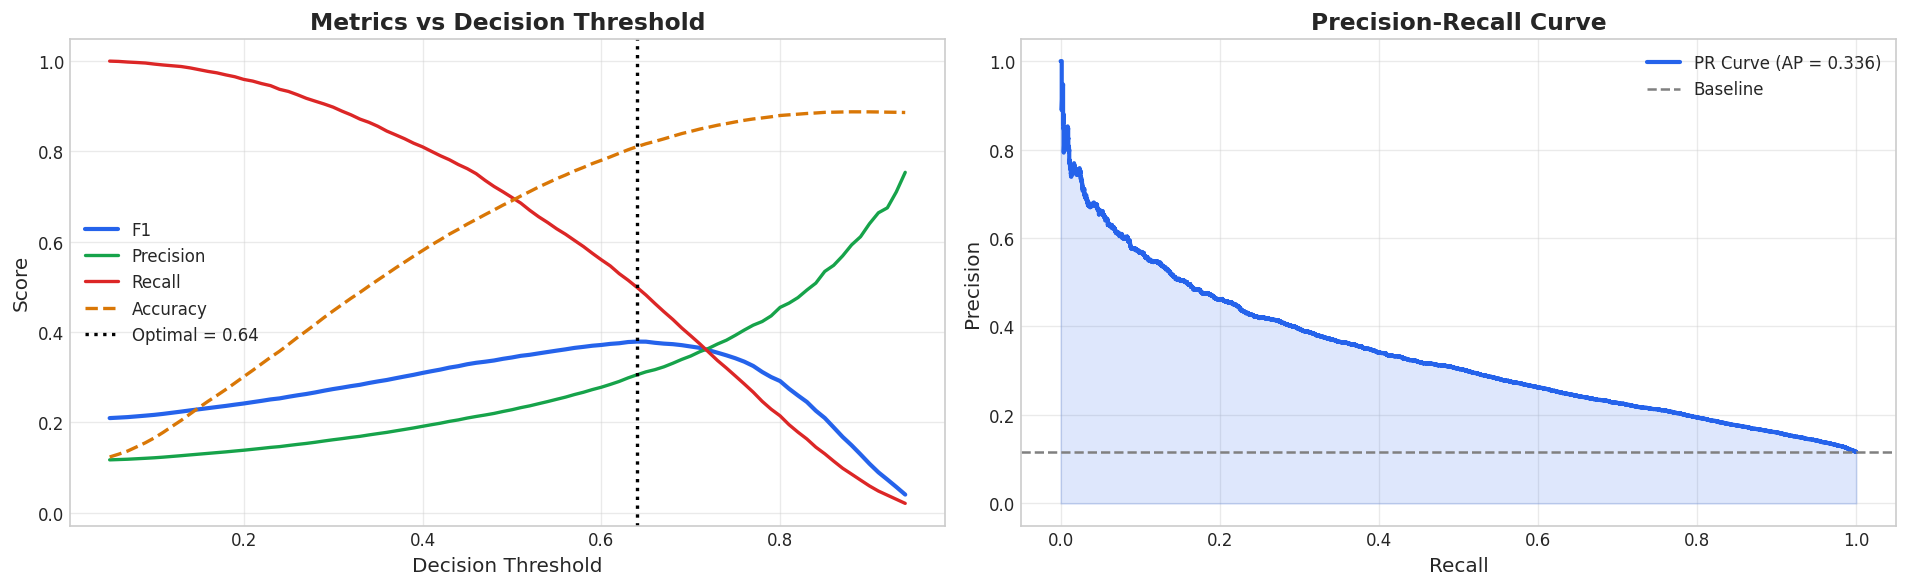

Optimal threshold selected: 0.64


In [33]:
# ===================================================
# CELL 10: Optimal Decision Threshold Selection
# ===================================================
print('=' * 60)
print('OPTIMAL DECISION THRESHOLD SELECTION')
print('=' * 60)

# Predict probabilities on test set (default threshold = 0.5)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Sweep thresholds and find the one maximizing F1
thresholds   = np.arange(0.05, 0.95, 0.01)
f1_scores    = []
prec_scores  = []
recall_scores= []
acc_scores   = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))
    prec_scores.append(precision_score(y_test, y_pred_t, zero_division=0))
    recall_scores.append(recall_score(y_test, y_pred_t, zero_division=0))
    acc_scores.append(accuracy_score(y_test, y_pred_t))

best_idx       = np.argmax(f1_scores)
optimal_thresh = thresholds[best_idx]

print(f'Optimal threshold: {optimal_thresh:.2f}')
print(f'Best F1 at threshold: {f1_scores[best_idx]:.4f}')

# Plot threshold curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresholds, f1_scores,     label='F1',        linewidth=2.5, color=PALETTE[0])
axes[0].plot(thresholds, prec_scores,   label='Precision',  linewidth=2,   color=PALETTE[2])
axes[0].plot(thresholds, recall_scores, label='Recall',     linewidth=2,   color=PALETTE[1])
axes[0].plot(thresholds, acc_scores,    label='Accuracy',   linewidth=2,   color=PALETTE[3], linestyle='--')
axes[0].axvline(x=optimal_thresh, color='black', linestyle=':', linewidth=2,
                label=f'Optimal = {optimal_thresh:.2f}')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs Decision Threshold', fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.4)

# Precision-Recall curve
pr_precision, pr_recall, pr_thresh = precision_recall_curve(y_test, y_prob)
avg_prec = average_precision_score(y_test, y_prob)

axes[1].plot(pr_recall, pr_precision, color=PALETTE[0], linewidth=2.5,
             label=f'PR Curve (AP = {avg_prec:.3f})')
axes[1].fill_between(pr_recall, pr_precision, alpha=0.15, color=PALETTE[0])
axes[1].axhline(y=y_test.mean(), color='gray', linestyle='--', linewidth=1.5, label='Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Optimal threshold selected: {optimal_thresh:.2f}')

In [34]:
# ===================================================
# CELL 11: Final Predictions with Optimal Threshold
# ===================================================
print('=' * 60)
print('FINAL MODEL EVALUATION')
print('=' * 60)

# Default threshold (0.5) predictions
y_pred_default = best_model.predict(X_test_scaled)

# Optimal threshold predictions
y_pred_optimal = (y_prob >= optimal_thresh).astype(int)

# Train predictions
y_train_prob = best_model.predict_proba(X_train_sm)[:, 1]
y_train_pred = (y_train_prob >= optimal_thresh).astype(int)

def compute_metrics(y_true, y_pred, y_proba, label):
    """Compute and return all classification metrics."""
    metrics = {
        'Accuracy'  : accuracy_score(y_true, y_pred),
        'Precision' : precision_score(y_true, y_pred, zero_division=0),
        'Recall'    : recall_score(y_true, y_pred, zero_division=0),
        'F1-Score'  : f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_true, y_proba),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
        'MCC'       : matthews_corrcoef(y_true, y_pred),
    }
    print(f'\n--- {label} ---')
    for k, v in metrics.items():
        print(f'  {k:15}: {v:.4f}')
    return metrics

# Default threshold
metrics_default = compute_metrics(y_test, y_pred_default, y_prob, 'DEFAULT THRESHOLD (0.50)')

# Optimal threshold
metrics_optimal = compute_metrics(y_test, y_pred_optimal, y_prob,
                                  f'OPTIMAL THRESHOLD ({optimal_thresh:.2f})')

# Training metrics
metrics_train = compute_metrics(y_train_sm, y_train_pred, y_train_prob, 'TRAINING SET')

print('\n=== DETAILED CLASSIFICATION REPORT (Optimal Threshold) ===')
print(classification_report(
    y_test, y_pred_optimal,
    target_names=['No Default', 'Default'],
    zero_division=0
))

FINAL MODEL EVALUATION

--- DEFAULT THRESHOLD (0.50) ---
  Accuracy       : 0.6903
  Precision      : 0.2278
  Recall         : 0.6975
  F1-Score       : 0.3434
  ROC-AUC        : 0.7614
  Balanced Acc   : 0.6934
  MCC            : 0.2589

--- OPTIMAL THRESHOLD (0.64) ---
  Accuracy       : 0.8099
  Precision      : 0.3052
  Recall         : 0.4984
  F1-Score       : 0.3785
  ROC-AUC        : 0.7614
  Balanced Acc   : 0.6746
  MCC            : 0.2854

--- TRAINING SET ---
  Accuracy       : 0.6685
  Precision      : 0.7662
  Recall         : 0.4850
  F1-Score       : 0.5940
  ROC-AUC        : 0.7677
  Balanced Acc   : 0.6685
  MCC            : 0.3623

=== DETAILED CLASSIFICATION REPORT (Optimal Threshold) ===
              precision    recall  f1-score   support

  No Default       0.93      0.85      0.89     45139
     Default       0.31      0.50      0.38      5931

    accuracy                           0.81     51070
   macro avg       0.62      0.67      0.63     51070
weighted 

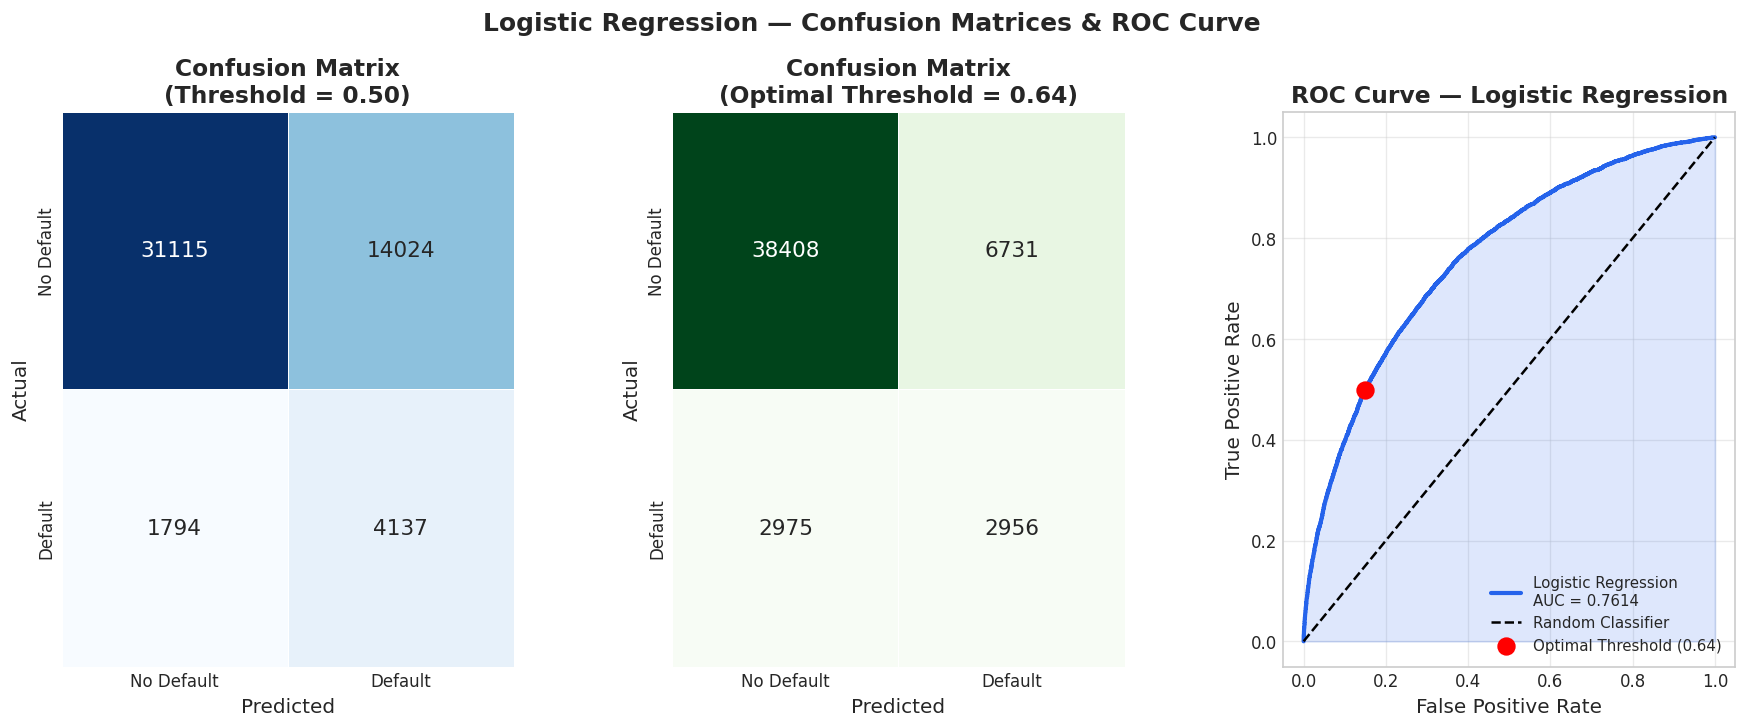

Evaluation plots saved!


In [35]:
# ===================================================
# CELL 12: Confusion Matrix & ROC Curve
# ===================================================
fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# --- Confusion matrix (default threshold) ---
ax0 = fig.add_subplot(gs[0])
cm_default = confusion_matrix(y_test, y_pred_default)
cm_norm    = cm_default.astype('float') / cm_default.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            annot_kws={'size': 13}, linewidths=0.5, ax=ax0, cbar=False)
ax0.set_title('Confusion Matrix\n(Threshold = 0.50)', fontweight='bold')
ax0.set_ylabel('Actual', fontsize=12)
ax0.set_xlabel('Predicted', fontsize=12)

# --- Confusion matrix (optimal threshold) ---
ax1 = fig.add_subplot(gs[1])
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'],
            annot_kws={'size': 13}, linewidths=0.5, ax=ax1, cbar=False)
ax1.set_title(f'Confusion Matrix\n(Optimal Threshold = {optimal_thresh:.2f})',
              fontweight='bold')
ax1.set_ylabel('Actual', fontsize=12)
ax1.set_xlabel('Predicted', fontsize=12)

# --- ROC Curve ---
ax2 = fig.add_subplot(gs[2])
fpr, tpr, roc_thresh = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

ax2.plot(fpr, tpr, color=PALETTE[0], linewidth=2.5,
         label=f'Logistic Regression\nAUC = {roc_auc:.4f}')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
ax2.fill_between(fpr, tpr, alpha=0.15, color=PALETTE[0])

# Mark optimal threshold on ROC
opt_fpr_idx = np.argmin(np.abs(roc_thresh - optimal_thresh))
ax2.scatter(fpr[opt_fpr_idx], tpr[opt_fpr_idx],
            color='red', zorder=5, s=100, label=f'Optimal Threshold ({optimal_thresh:.2f})')

ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve — Logistic Regression', fontweight='bold')
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(alpha=0.4)

plt.suptitle('Logistic Regression — Confusion Matrices & ROC Curve',
             fontsize=15, fontweight='bold', y=1.02)
plt.savefig(f'{RESULTS_DIR}/logistic_regression_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Evaluation plots saved!')

FEATURE IMPORTANCE — Logistic Regression Coefficients

Top 20 Features by Coefficient Magnitude:
                     Feature  Coefficient  Abs_Coef
                LoanToIncome     0.534653  0.534653
                InterestRate     0.509997  0.509997
              MonthsEmployed    -0.405630  0.405630
                         Age    -0.385411  0.385411
                  AgeXIncome    -0.279376  0.279376
   EmploymentType_Unemployed     0.200073  0.200073
                  Log_Income     0.187853  0.187853
                 CreditScore    -0.187133  0.187133
              Log_LoanAmount     0.164818  0.164818
                 HasCoSigner    -0.149808  0.149808
               HasDependents    -0.144902  0.144902
                  LoanAmount    -0.133213  0.133213
    EmploymentType_Part-time     0.124024  0.124024
              NumCreditLines     0.123852  0.123852
       MaritalStatus_Married    -0.119044  0.119044
                   Education    -0.117492  0.117492
                Int

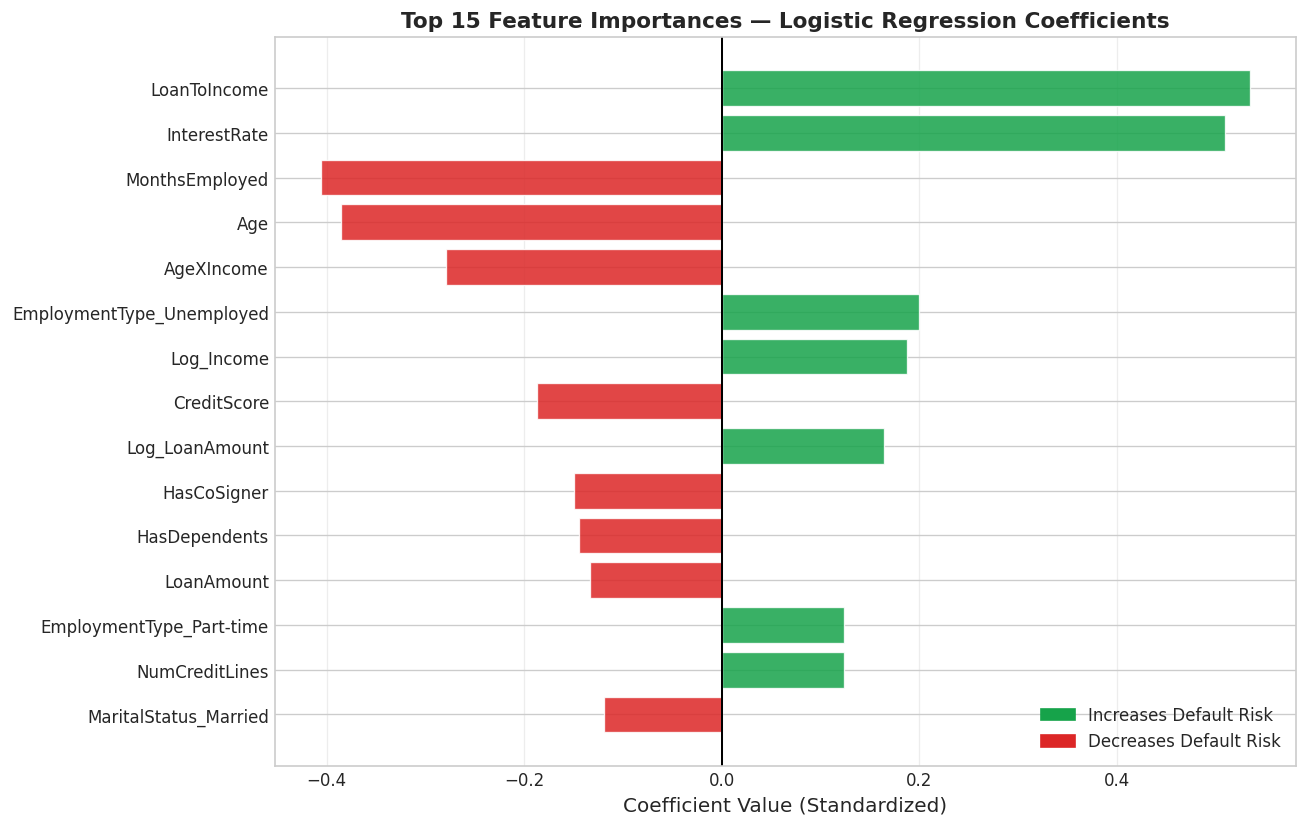

Feature importance plot saved!


In [36]:
# ===================================================
# CELL 13: Feature Importance (Coefficients)
# ===================================================
print('=' * 60)
print('FEATURE IMPORTANCE — Logistic Regression Coefficients')
print('=' * 60)

coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': best_model.coef_[0]
})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

print('\nTop 20 Features by Coefficient Magnitude:')
print(coef_df.head(20).to_string(index=False))

# Plot top 15
top15 = coef_df.head(15).iloc[::-1]  # reverse for horizontal bar
colors = [PALETTE[2] if x > 0 else PALETTE[1] for x in top15['Coefficient']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(range(len(top15)), top15['Coefficient'],
               color=colors, alpha=0.85, edgecolor='white', linewidth=0.8)

ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Feature'], fontsize=10)
ax.set_xlabel('Coefficient Value (Standardized)', fontsize=12)
ax.set_title('Top 15 Feature Importances — Logistic Regression Coefficients',
             fontsize=13, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=1.2)
ax.grid(axis='x', alpha=0.35)

# Legend
from matplotlib.patches import Patch
legend_els = [Patch(color=PALETTE[2], label='Increases Default Risk'),
              Patch(color=PALETTE[1], label='Decreases Default Risk')]
ax.legend(handles=legend_els, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance plot saved!')

Generating learning curves...


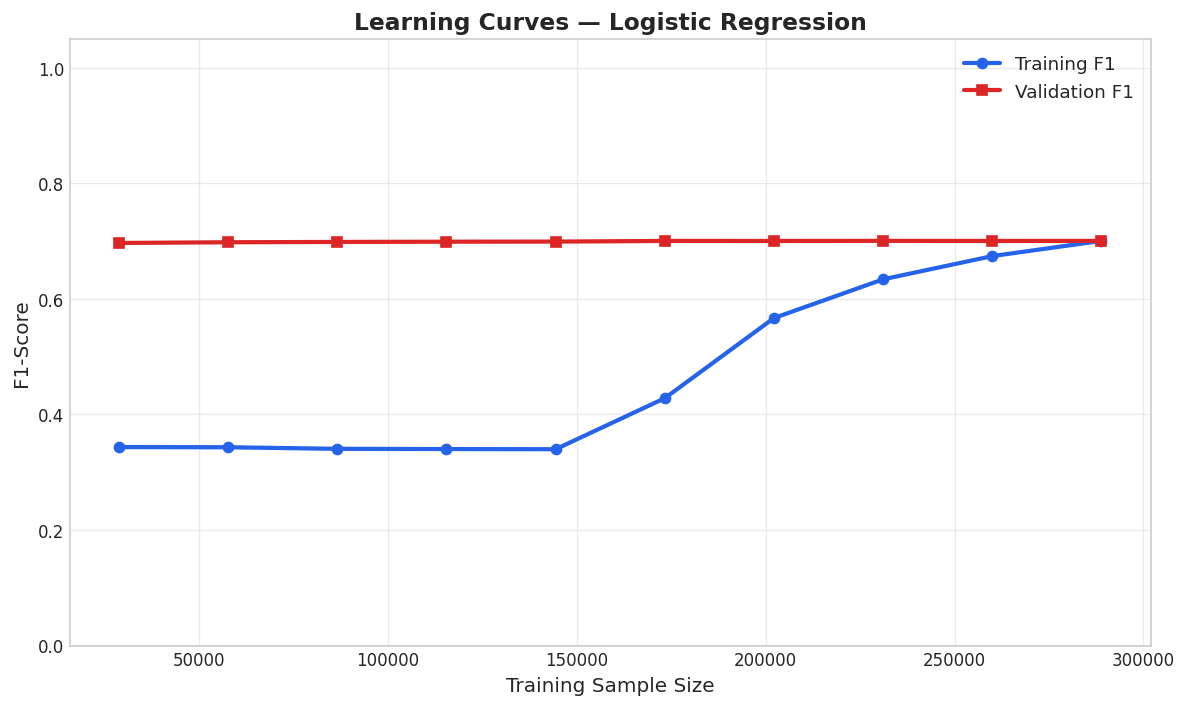

Learning curves saved!


In [37]:
# ===================================================
# CELL 14: Learning Curves
# ===================================================
print('Generating learning curves...')

train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_sm, y_train_sm,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color=PALETTE[0],
        label='Training F1', linewidth=2.5)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color=PALETTE[0])
ax.plot(train_sizes, val_mean, 's-', color=PALETTE[1],
        label='Validation F1', linewidth=2.5)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color=PALETTE[1])
ax.set_xlabel('Training Sample Size', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Learning Curves — Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.4)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Learning curves saved!')

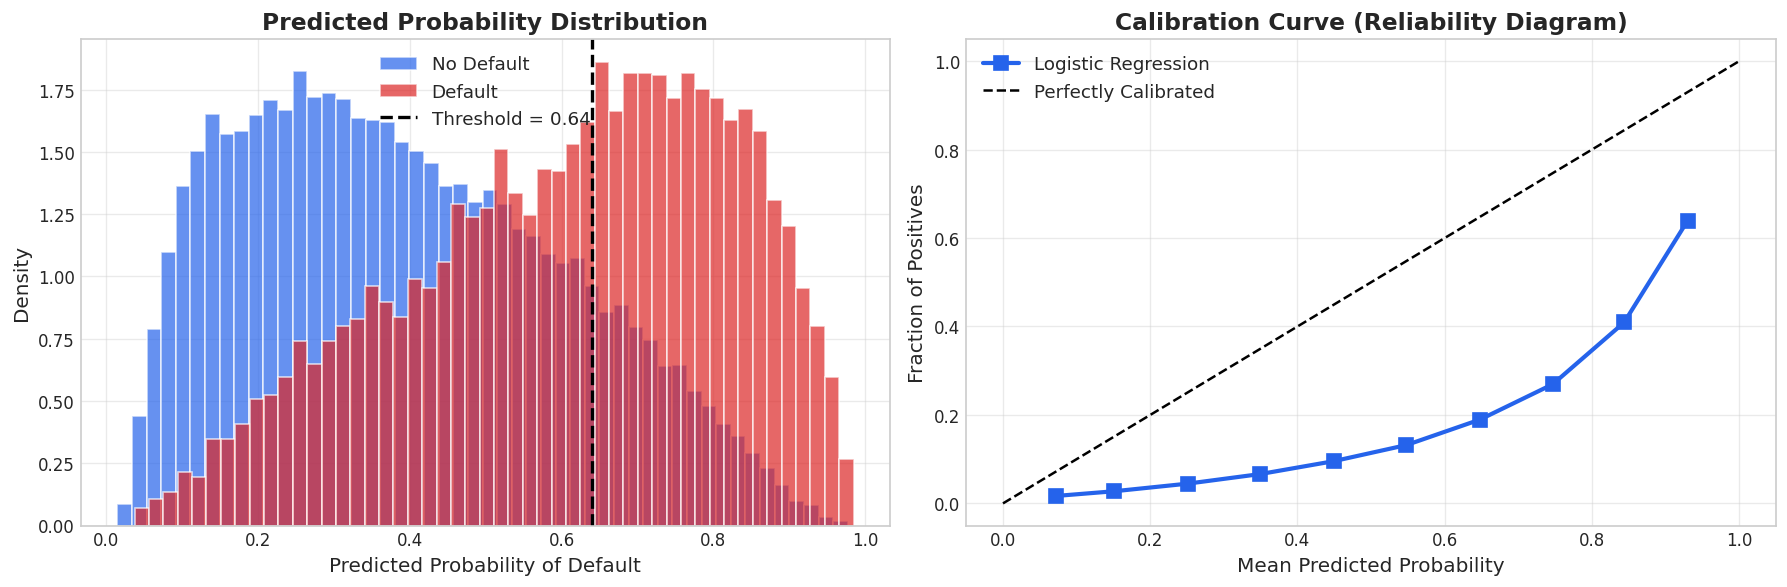

Probability distribution and calibration plots saved!


In [38]:
# ===================================================
# CELL 15: Probability Distribution & Calibration
# ===================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Predicted probability distribution ---
axes[0].hist(y_prob[y_test == 0], bins=50, alpha=0.7, color=PALETTE[0],
             label='No Default', density=True, edgecolor='white')
axes[0].hist(y_prob[y_test == 1], bins=50, alpha=0.7, color=PALETTE[1],
             label='Default', density=True, edgecolor='white')
axes[0].axvline(x=optimal_thresh, color='black', linestyle='--', linewidth=2,
                label=f'Threshold = {optimal_thresh:.2f}')
axes[0].set_xlabel('Predicted Probability of Default', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Predicted Probability Distribution', fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.4)

# --- Calibration Curve ---
fraction_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10, strategy='uniform')
axes[1].plot(mean_pred, fraction_pos, 's-', color=PALETTE[0],
             linewidth=2.5, markersize=8, label='Logistic Regression')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfectly Calibrated')
axes[1].set_xlabel('Mean Predicted Probability', fontsize=12)
axes[1].set_ylabel('Fraction of Positives', fontsize=12)
axes[1].set_title('Calibration Curve (Reliability Diagram)', fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/probability_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Probability distribution and calibration plots saved!')

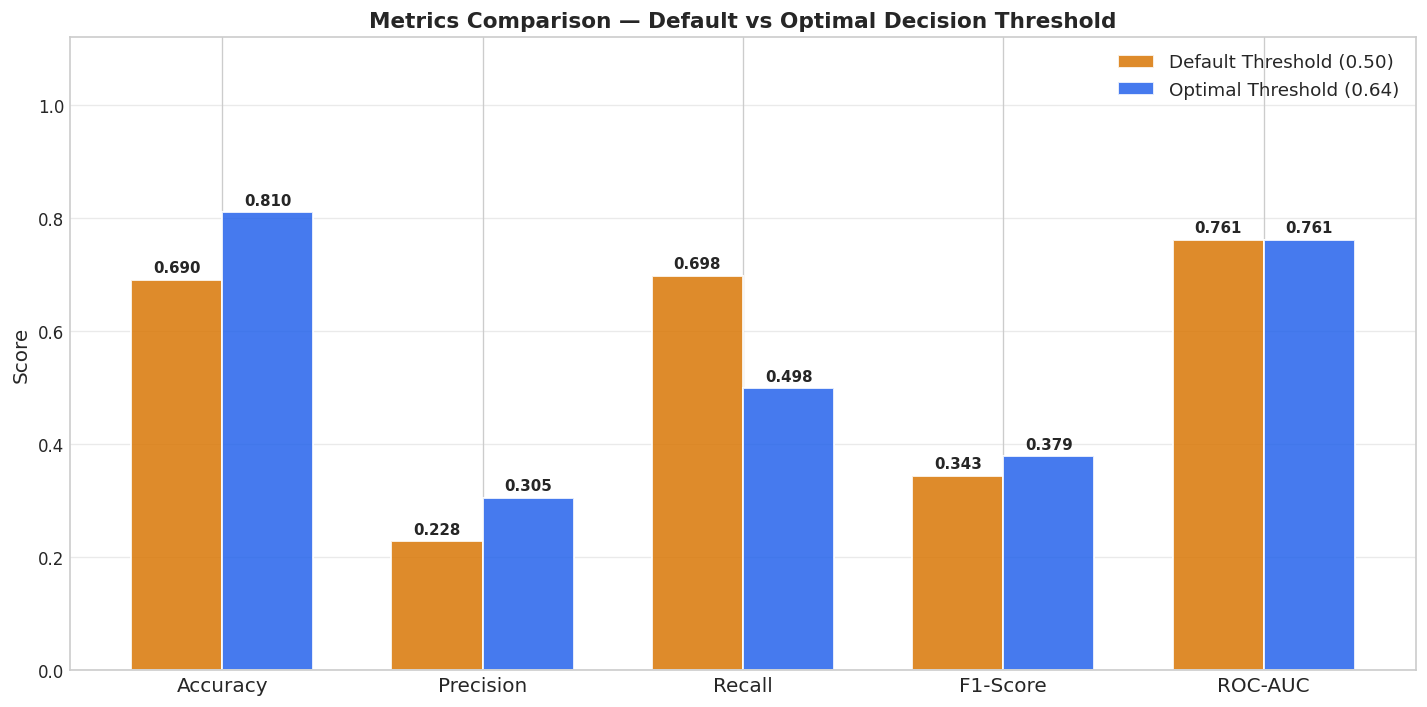

Metrics comparison saved!


In [39]:
# ===================================================
# CELL 16: Metrics Comparison — Default vs Optimal Threshold
# ===================================================
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

default_vals = [
    metrics_default['Accuracy'],
    metrics_default['Precision'],
    metrics_default['Recall'],
    metrics_default['F1-Score'],
    metrics_default['ROC-AUC'],
]
optimal_vals = [
    metrics_optimal['Accuracy'],
    metrics_optimal['Precision'],
    metrics_optimal['Recall'],
    metrics_optimal['F1-Score'],
    metrics_optimal['ROC-AUC'],
]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, default_vals, width, label='Default Threshold (0.50)',
               color=PALETTE[3], alpha=0.85, edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, optimal_vals, width,
               label=f'Optimal Threshold ({optimal_thresh:.2f})',
               color=PALETTE[0], alpha=0.85, edgecolor='white', linewidth=1.2)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.008,
            f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_title('Metrics Comparison — Default vs Optimal Decision Threshold',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/threshold_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Metrics comparison saved!')

In [40]:
# ===================================================
# CELL 17: Save All Results to Files
# ===================================================
import json

# Save results CSV
results_df = pd.DataFrame({
    'Model'                 : ['Logistic Regression'],
    'Best_C'                : [best_model.C],
    'Best_Penalty'          : [best_model.penalty],
    'Best_Solver'           : [best_model.solver],
    'Optimal_Threshold'     : [round(float(optimal_thresh), 2)],
    'Train_Accuracy'        : [round(metrics_train['Accuracy'], 4)],
    'Train_F1'              : [round(metrics_train['F1-Score'], 4)],
    'Test_Accuracy_Default' : [round(metrics_default['Accuracy'], 4)],
    'Test_Precision_Default': [round(metrics_default['Precision'], 4)],
    'Test_Recall_Default'   : [round(metrics_default['Recall'], 4)],
    'Test_F1_Default'       : [round(metrics_default['F1-Score'], 4)],
    'Test_Accuracy_Optimal' : [round(metrics_optimal['Accuracy'], 4)],
    'Test_Precision_Optimal': [round(metrics_optimal['Precision'], 4)],
    'Test_Recall_Optimal'   : [round(metrics_optimal['Recall'], 4)],
    'Test_F1_Optimal'       : [round(metrics_optimal['F1-Score'], 4)],
    'Test_ROC_AUC'          : [round(metrics_optimal['ROC-AUC'], 4)],
    'Test_MCC'              : [round(metrics_optimal['MCC'], 4)],
    'Test_BalancedAcc'      : [round(metrics_optimal['Balanced Acc'], 4)],
})

results_df.to_csv(f'{RESULTS_DIR}/logistic_regression_results.csv', index=False)
print('Results CSV saved!')
print(results_df.T.to_string())

Results CSV saved!
                                          0
Model                   Logistic Regression
Best_C                                   10
Best_Penalty                             l2
Best_Solver                           lbfgs
Optimal_Threshold                      0.64
Train_Accuracy                       0.6685
Train_F1                              0.594
Test_Accuracy_Default                0.6903
Test_Precision_Default               0.2278
Test_Recall_Default                  0.6975
Test_F1_Default                      0.3434
Test_Accuracy_Optimal                0.8099
Test_Precision_Optimal               0.3052
Test_Recall_Optimal                  0.4984
Test_F1_Optimal                      0.3785
Test_ROC_AUC                         0.7614
Test_MCC                             0.2854
Test_BalancedAcc                     0.6746


In [41]:
# ===================================================
# CELL 18: FINAL COMPREHENSIVE SUMMARY
# ===================================================
rating = (
    'EXCELLENT' if metrics_optimal['F1-Score'] > 0.80 else
    'VERY GOOD' if metrics_optimal['F1-Score'] > 0.70 else
    'GOOD'      if metrics_optimal['F1-Score'] > 0.60 else 'FAIR'
)

summary = f"""
{'='*65}
 LOGISTIC REGRESSION — LOAN DEFAULT PREDICTION
 FINAL RESULTS SUMMARY
{'='*65}

DATASET:
  Source          : Coursera Loan Default Prediction (Kaggle)
  Total Samples   : {len(df):,}
  Features Used   : {X.shape[1]} (including 8 engineered features)
  Target          : Default (1=Default, 0=No Default)

PREPROCESSING:
  - Dropped LoanID (non-predictive)
  - Outlier capping (1st/99th percentile)  
  - Binary encoding: HasMortgage, HasDependents, HasCoSigner
  - Ordinal encoding: Education
  - One-hot encoding: EmploymentType, MaritalStatus, LoanPurpose
  - Feature engineering: LoanToIncome, InterestXDTI, RiskScore, etc.
  - StandardScaler normalization
  - SMOTE oversampling (training only)

BEST HYPERPARAMETERS:
  C (Regularization) : {best_model.C}
  Penalty            : {best_model.penalty}
  Solver             : {best_model.solver}
  Optimal Threshold  : {optimal_thresh:.2f}
  (Tuned via 5-fold GridSearchCV, scoring=F1)

TEST RESULTS (Default Threshold = 0.50):
  Accuracy   : {metrics_default['Accuracy']:.4f} ({metrics_default['Accuracy']*100:.2f}%)
  Precision  : {metrics_default['Precision']:.4f}
  Recall     : {metrics_default['Recall']:.4f}
  F1-Score   : {metrics_default['F1-Score']:.4f}
  ROC-AUC    : {metrics_default['ROC-AUC']:.4f}

TEST RESULTS (Optimal Threshold = {optimal_thresh:.2f}):
  Accuracy   : {metrics_optimal['Accuracy']:.4f} ({metrics_optimal['Accuracy']*100:.2f}%)
  Precision  : {metrics_optimal['Precision']:.4f}
  Recall     : {metrics_optimal['Recall']:.4f}
  F1-Score   : {metrics_optimal['F1-Score']:.4f}
  ROC-AUC    : {metrics_optimal['ROC-AUC']:.4f}
  MCC        : {metrics_optimal['MCC']:.4f}
  Balanced Acc: {metrics_optimal['Balanced Acc']:.4f}

CONFUSION MATRIX (Optimal Threshold):
  True Negatives  (TN): {cm_optimal[0,0]:,}  (Correctly predicted: No Default)
  False Positives (FP): {cm_optimal[0,1]:,}  (Type I Error)
  False Negatives (FN): {cm_optimal[1,0]:,}  (Type II Error)
  True Positives  (TP): {cm_optimal[1,1]:,}  (Correctly predicted: Default)

TOP 5 PREDICTIVE FEATURES:
  1. {coef_df.iloc[0]['Feature']:30} coef = {coef_df.iloc[0]['Coefficient']:+.4f}
  2. {coef_df.iloc[1]['Feature']:30} coef = {coef_df.iloc[1]['Coefficient']:+.4f}
  3. {coef_df.iloc[2]['Feature']:30} coef = {coef_df.iloc[2]['Coefficient']:+.4f}
  4. {coef_df.iloc[3]['Feature']:30} coef = {coef_df.iloc[3]['Coefficient']:+.4f}
  5. {coef_df.iloc[4]['Feature']:30} coef = {coef_df.iloc[4]['Coefficient']:+.4f}

PERFORMANCE RATING: {rating}

FILES SAVED TO {RESULTS_DIR}/:
  - logistic_regression_results.csv       (all metrics)
  - logistic_regression_evaluation.png    (confusion matrix + ROC)
  - feature_importance.png                (top 15 features)
  - threshold_analysis.png                (threshold sweep)
  - cv_results.png                        (cross-validation)
  - learning_curves.png                   (learning curves)
  - probability_calibration.png           (probability calibration)
  - threshold_metrics_comparison.png      (default vs optimal)
  - eda_class_distribution.png            (EDA)
  - eda_correlation_heatmap.png           (correlation)
  - FINAL_SUMMARY.txt                     (this summary)
{'='*65}
"""

print(summary)

with open(f'{RESULTS_DIR}/FINAL_SUMMARY.txt', 'w', encoding='utf-8') as f:
    f.write(summary)

print('All results saved successfully!')


 LOGISTIC REGRESSION — LOAN DEFAULT PREDICTION
 FINAL RESULTS SUMMARY

DATASET:
  Source          : Coursera Loan Default Prediction (Kaggle)
  Total Samples   : 255,347
  Features Used   : 30 (including 8 engineered features)
  Target          : Default (1=Default, 0=No Default)

PREPROCESSING:
  - Dropped LoanID (non-predictive)
  - Outlier capping (1st/99th percentile)  
  - Binary encoding: HasMortgage, HasDependents, HasCoSigner
  - Ordinal encoding: Education
  - One-hot encoding: EmploymentType, MaritalStatus, LoanPurpose
  - Feature engineering: LoanToIncome, InterestXDTI, RiskScore, etc.
  - StandardScaler normalization
  - SMOTE oversampling (training only)

BEST HYPERPARAMETERS:
  C (Regularization) : 10
  Penalty            : l2
  Solver             : lbfgs
  Optimal Threshold  : 0.64
  (Tuned via 5-fold GridSearchCV, scoring=F1)

TEST RESULTS (Default Threshold = 0.50):
  Accuracy   : 0.6903 (69.03%)
  Precision  : 0.2278
  Recall     : 0.6975
  F1-Score   : 0.3434
  ROC-